In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer

from collections import defaultdict
from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed, load
from tqdm.notebook import tqdm

import ast
import glob
import pickle
import dask
import os
import itertools

import dask.dataframe as dd
from dask.distributed import Client

from concurrent.futures import ThreadPoolExecutor

from pprint import pprint

In [2]:
def read_csv(file):
    return pd.read_csv(file)

def read_pickle(file):
    with open(file, "rb") as f:
        df = pickle.load(f)
    return df

In [3]:
kmeans_tcv_2nd_design_dir = "kmeans_tcv_2nd_design"
kmeans_tcv_1st_design_dir = "kmeans_tcv_1st_design"

K_list = [1] + list(range(100,3200,100)) + [3136]

In [4]:
def generate_design_results_dict(K_list, directory):
    design_results_dict = {}
    for K in tqdm(K_list):
        design_results_dict[K] = []
        pattern = "metrics_df_({},*.csv".format(K)
        files = glob.glob(os.path.join(directory,pattern))
        # empty list to store dataframes
        with ThreadPoolExecutor() as executor:
            results = executor.map(read_csv, files)
            for result in results:
                design_results_dict[K].append(result)
    return design_results_dict

In [5]:
first_design_results_dict = generate_design_results_dict(K_list, kmeans_tcv_1st_design_dir)
second_design_results_dict = generate_design_results_dict(K_list, kmeans_tcv_2nd_design_dir)

In [6]:
def generate_merged_df_dict(design_results_dict, K_list):
    merged_df_dict = {}
    for K in tqdm(K_list):
        #print(K)
        dfs = design_results_dict[K]
        merged_df = pd.concat(dfs)

        # Group the dataframe by 'days_from_start' and sum the 'mse' and 'mae' columns
        merged_df = merged_df.groupby('days_from_start', as_index=False).agg({'total_mse': 'sum', 'total_mae': 'sum', 'nsamples_mse': 'sum', 'nsamples_mae': 'sum'})

        # Keep the other columns that overlap 'days_from_start' identical by using 'first' aggregation
        merged_df = merged_df.groupby('days_from_start', as_index=False).first()

        merged_df["rmse"] =  np.sqrt(merged_df["total_mse"] / merged_df["nsamples_mse"])
        merged_df["mae"] = (merged_df["total_mae"] / merged_df["nsamples_mae"])

        merged_df_dict[K] = merged_df#[merged_df["days_from_start"] >= 51]
    return merged_df_dict
    

In [7]:
first_design_merged_df_dict = generate_merged_df_dict(first_design_results_dict, K_list)
second_design_merged_df_dict = generate_merged_df_dict(second_design_results_dict, K_list)

In [8]:
with open('first_design_merged_df_dict.pickle', 'wb') as file:
    pickle.dump(first_design_merged_df_dict, file)
with open('second_design_merged_df_dict.pickle', 'wb') as file:
    pickle.dump(second_design_merged_df_dict, file)


In [9]:
np.sqrt(1260.675177/3136), 2746.638017/3136

(0.6340354982759085, 0.8758412044005103)

/home/zwang937/anaconda3/lib/python3.7/site-packages/pandas/core/indexes/range.py:839: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  return super().__getitem__(key)
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


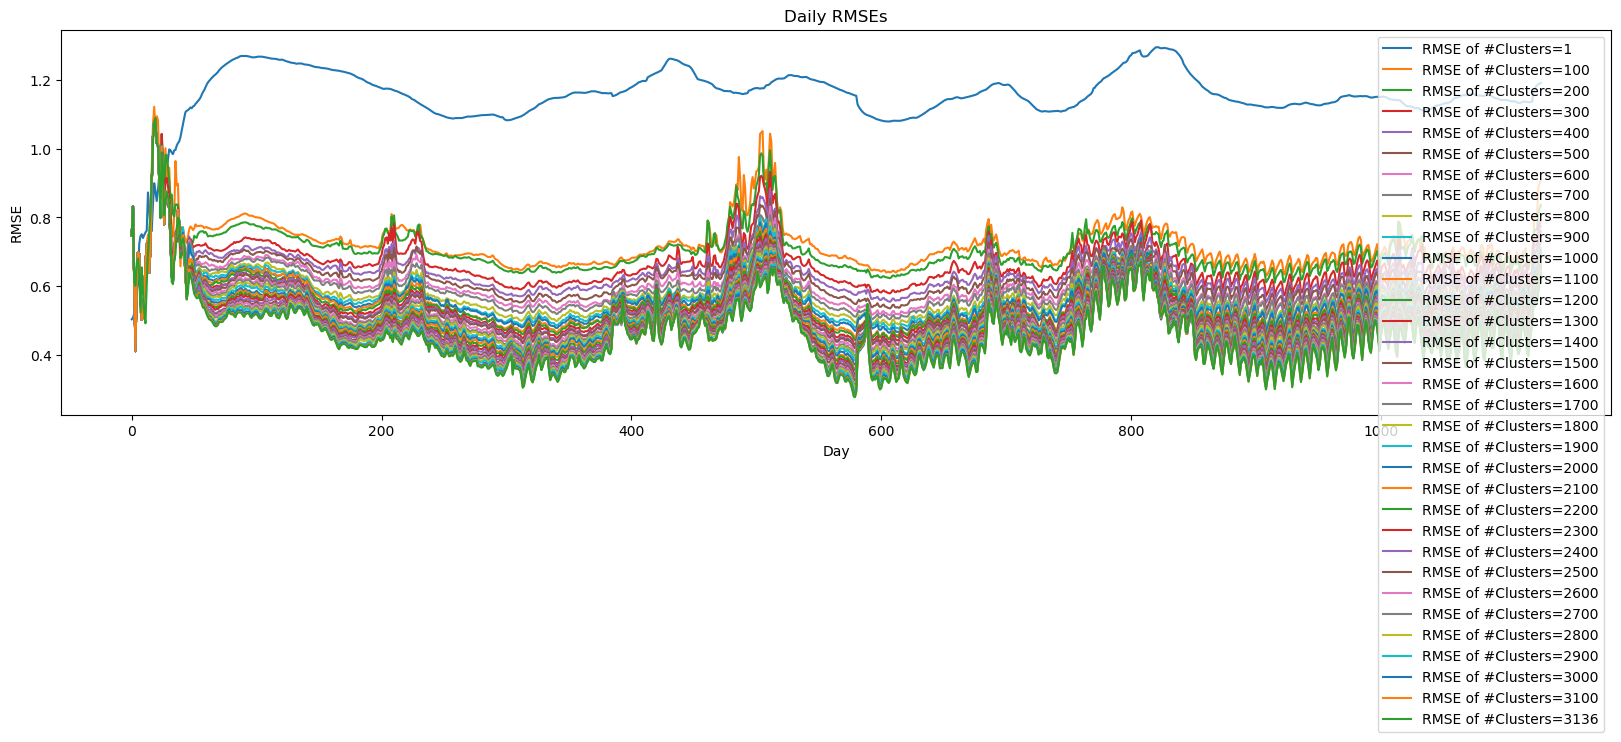

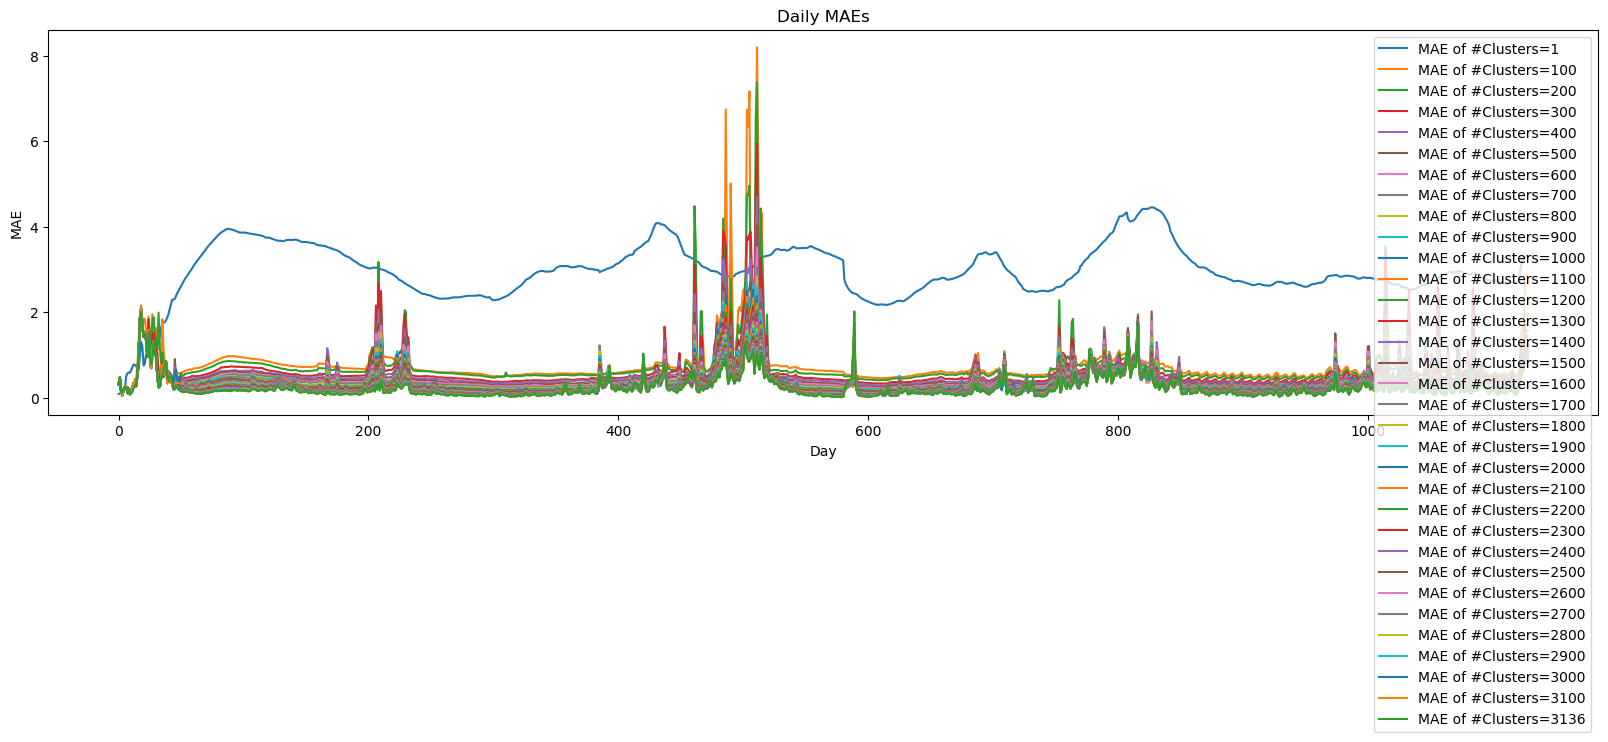

In [10]:
# Plot the daily RMSEs for each dataframe
figsize=(20,5)
plt.subplots(figsize=figsize)

for K, df in first_design_merged_df_dict.items():
    plt.plot(df.index, df['rmse'], label='RMSE of #Clusters={}'.format(K))

# Add a legend to the first subplot
plt.legend()
plt.title('Daily RMSEs')
plt.xlabel('Day')
plt.ylabel('RMSE')

plt.show()
plt.subplots(figsize=figsize)
for K, df in first_design_merged_df_dict.items():
    plt.plot(df.index, df['mae'], label='MAE of #Clusters={}'.format(K))

# Add a legend to the first subplot
plt.legend()
plt.title('Daily MAEs')
plt.xlabel('Day')
plt.ylabel('MAE')

plt.show()

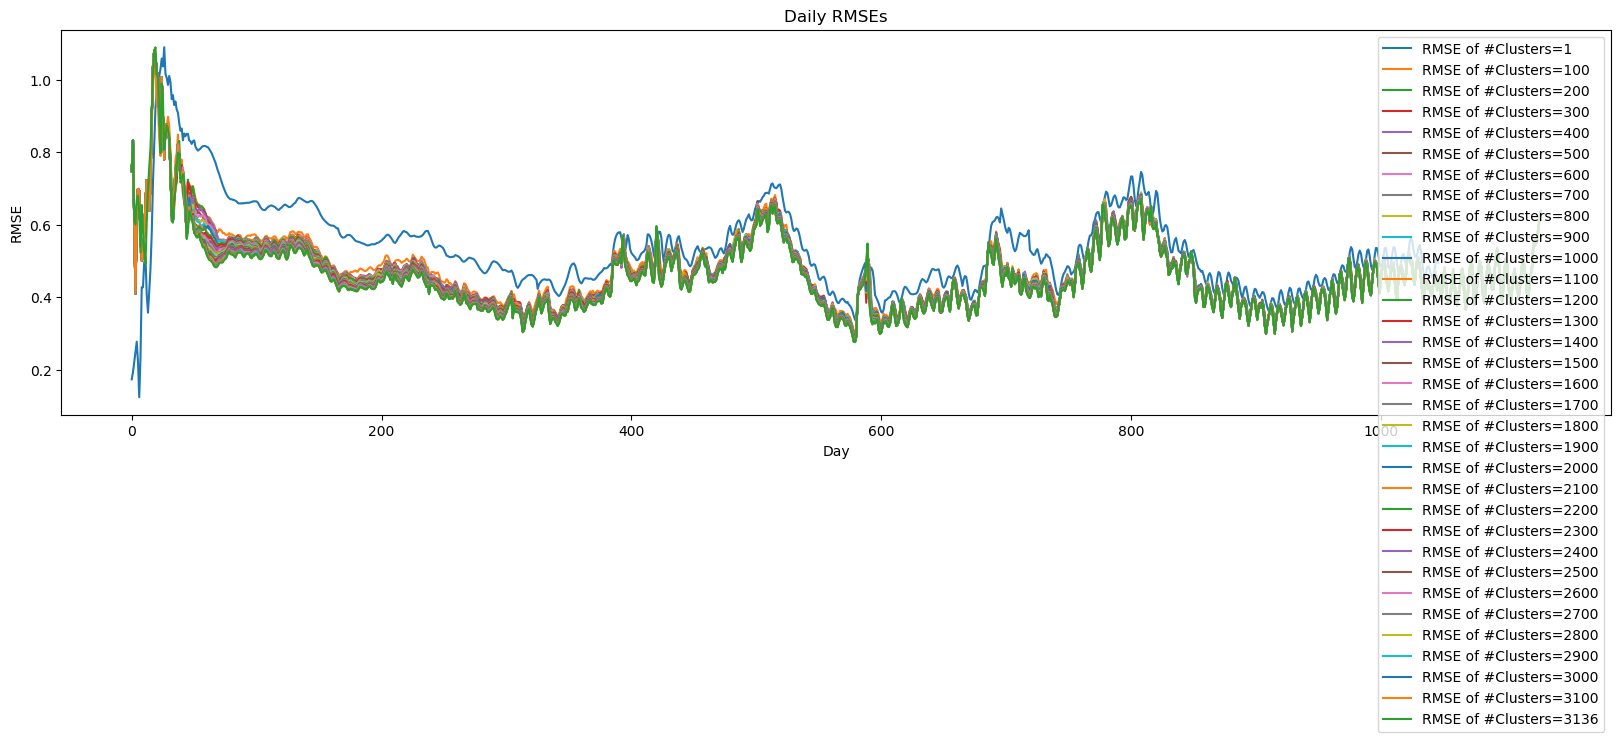

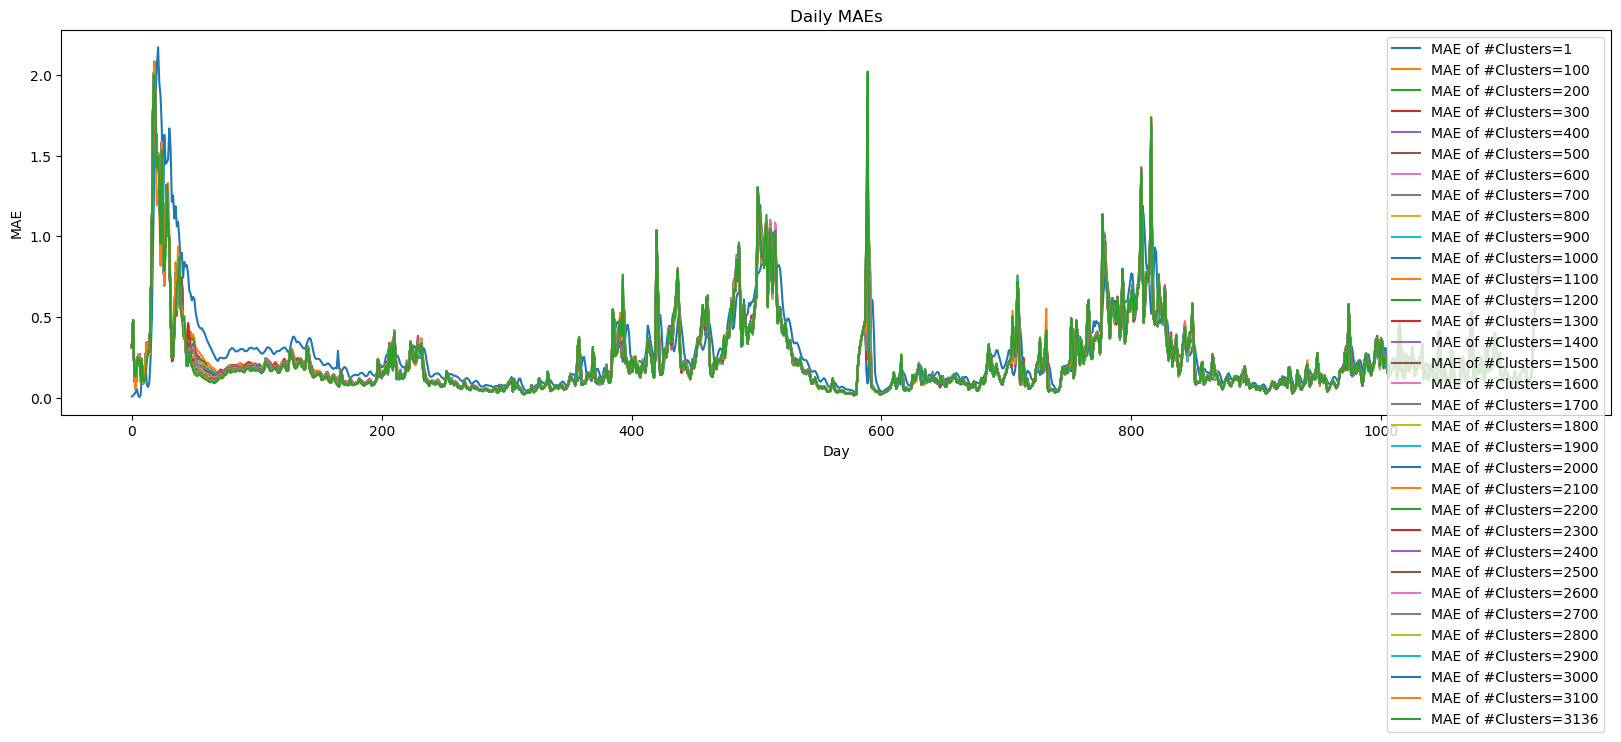

In [11]:
# Plot the daily RMSEs for each dataframe
figsize=(20,5)
plt.subplots(figsize=figsize)

for K, df in second_design_merged_df_dict.items():
    plt.plot(df.index, df['rmse'], label='RMSE of #Clusters={}'.format(K))

# Add a legend to the first subplot
plt.legend()
plt.title('Daily RMSEs')
plt.xlabel('Day')
plt.ylabel('RMSE')

plt.show()
plt.subplots(figsize=figsize)
for K, df in second_design_merged_df_dict.items():
    plt.plot(df.index, df['mae'], label='MAE of #Clusters={}'.format(K))

# Add a legend to the first subplot
plt.legend()
plt.title('Daily MAEs')
plt.xlabel('Day')
plt.ylabel('MAE')

plt.show()

In [12]:
first_median_dict = {K: df.median() for K, df in first_design_merged_df_dict.items()}
first_median_df = pd.DataFrame(first_median_dict).transpose()

# Add a column indicating the value of K
first_median_df.index.name = 'K'
first_median_df.reset_index(inplace=True)

# Rename the columns
first_median_df = first_median_df.rename(columns={'rmse': 'Median RMSE', 'mae': 'Median MAE'})
first_median_df = first_median_df.sort_values(by=["K"])
first_median_df = first_median_df[['K','Median RMSE','Median MAE', 'nsamples_mse', 'nsamples_mae']]

lowest_rmse_K_df = first_median_df.sort_values(by=["Median RMSE"]).iloc[0]
print("Cluster={} has lowest Median RMSE of {}, with median MAE of {}".format(lowest_rmse_K_df["K"], lowest_rmse_K_df["Median RMSE"], lowest_rmse_K_df["Median MAE"]))
lowest_mae_K_df = first_median_df.sort_values(by=["Median MAE"]).iloc[0]
print("Cluster={} has lowest Median MAE of {}, with median RMSE of {}".format(lowest_mae_K_df["K"], lowest_mae_K_df["Median MAE"], lowest_mae_K_df["Median RMSE"]))

#tcv_df = median_df.loc[median_df["K"]==1, ["Median RMSE", "Median MAE"]].values
#print("tcv i.e. Cluster=1 has Median MAE={}, Median RMSE={}".format(tcv_df[0][0], tcv_df[0][1]))
ctcv_df = first_median_df.loc[first_median_df["K"]==3136, ["Median RMSE", "Median MAE"]].values
print("ctcv i.e. Cluster=3136 has Median MAE={}, Median RMSE={}".format(ctcv_df[0,1], ctcv_df[0,0]))


Cluster=3136.0 has lowest Median RMSE of 0.43915338222223743, with median MAE of 0.15112973650473321
Cluster=3136.0 has lowest Median MAE of 0.15112973650473321, with median RMSE of 0.43915338222223743
ctcv i.e. Cluster=3136 has Median MAE=0.15112973650473321, Median RMSE=0.43915338222223743


In [13]:
second_median_dict = {K: df.median() for K, df in second_design_merged_df_dict.items()}
second_median_df = pd.DataFrame(second_median_dict).transpose()

# Add a column indicating the value of K
second_median_df.index.name = 'K'
second_median_df.reset_index(inplace=True)

# Rename the columns
second_median_df = second_median_df.rename(columns={'rmse': 'Median RMSE', 'mae': 'Median MAE'})
second_median_df = second_median_df.sort_values(by=["K"])
second_median_df = second_median_df[['K','Median RMSE','Median MAE', 'nsamples_mse', 'nsamples_mae']]

lowest_rmse_K_df = second_median_df.sort_values(by=["Median RMSE"]).iloc[0]
print("Cluster={} has lowest Median RMSE of {}, with median MAE of {}".format(lowest_rmse_K_df["K"], lowest_rmse_K_df["Median RMSE"], lowest_rmse_K_df["Median MAE"]))
lowest_mae_K_df = second_median_df.sort_values(by=["Median MAE"]).iloc[0]
print("Cluster={} has lowest Median MAE of {}, with median RMSE of {}".format(lowest_mae_K_df["K"], lowest_mae_K_df["Median MAE"], lowest_mae_K_df["Median RMSE"]))

#tcv_df = median_df.loc[median_df["K"]==1, ["Median RMSE", "Median MAE"]].values
#print("tcv i.e. Cluster=1 has Median MAE={}, Median RMSE={}".format(tcv_df[0][0], tcv_df[0][1]))
ctcv_df = second_median_df.loc[second_median_df["K"]==3136, ["Median RMSE", "Median MAE"]].values
print("ctcv i.e. Cluster=3136 has Median MAE={}, Median RMSE={}".format(ctcv_df[0,1], ctcv_df[0,0]))

Cluster=3100.0 has lowest Median RMSE of 0.43906736335856344, with median MAE of 0.151905831147874
Cluster=2700.0 has lowest Median MAE of 0.15083906913695885, with median RMSE of 0.4412367160223658
ctcv i.e. Cluster=3136 has Median MAE=0.15112973650473321, Median RMSE=0.43915338222223743


In [14]:
combined_median_df = pd.merge(first_median_df, second_median_df, on="K", how="inner", suffixes=("_first_design","_second_design"))
combined_median_df = combined_median_df[["K", "Median MAE_first_design", "Median MAE_second_design","Median RMSE_first_design", "Median RMSE_second_design"]]
display(combined_median_df)

,K,Median MAE_first_design,Median MAE_second_design,Median RMSE_first_design,Median RMSE_second_design
0,1,2.910928,0.199910,1.154925,0.518101
1,100,0.629669,0.166356,0.703995,0.467096
2,200,0.577771,0.163664,0.687975,0.459513
3,300,0.489536,0.164140,0.653949,0.460273
4,400,0.448983,0.161515,0.632314,0.459681
5,500,0.409943,0.161424,0.616870,0.459686
6,600,0.367080,0.158369,0.596749,0.459418
7,700,0.341578,0.159125,0.584756,0.457237
8,800,0.309364,0.159970,0.567687,0.457570
9,900,0.294465,0.159059,0.558455,0.455856


In [15]:
len(design_results_dict[2200])

NameError: name 'design_results_dict' is not defined

### Plot RMSE, MAE against K

In [ ]:
figsize=(20,10)
plt.subplots(figsize=figsize)

plt.plot(first_median_df["K"], first_median_df["Median RMSE"], label="1st Design Median RMSE")
plt.plot(second_median_df["K"], second_median_df["Median RMSE"], label="2nd Design Median RMSE")

plt.legend()
plt.title('Median of RMSEs by Cluster Number 1st Design vs 2nd Design')
plt.xlabel('K')
plt.ylabel('Median RMSE')

plt.show()

In [ ]:
figsize=(20,10)
plt.subplots(figsize=figsize)

plt.plot(first_median_df["K"], first_median_df["Median MAE"], label="1st Design Median MAE")
plt.plot(second_median_df["K"], second_median_df["Median MAE"], label="2nd Design Median MAE")

plt.legend()
plt.title('Median of MAEs by Cluster Number 1st Design vs 2nd Design')
plt.xlabel('K')
plt.ylabel('Median MAE')

plt.show()

In [ ]:
figsize=(20,10)
plt.subplots(figsize=figsize)

plt.plot(second_median_df["K"], second_median_df["Median RMSE"], label="Median RMSE 2nd Design")
# Add a legend to the first subplot
plt.legend()

plt.plot(second_median_df["K"], second_median_df["Median MAE"], label="Median MAE 2nd Design")
# Add a legend to the first subplot
plt.legend()
plt.title('Median RMSE and MAE of 2nd Design by Cluster Number')
plt.xlabel('K')
plt.ylabel('Median Error Metric')

plt.show()

In [ ]:
figsize=(20,10)
plt.subplots(figsize=figsize)

plt.plot(first_median_df["K"], first_median_df["Median RMSE"], label="Median RMSE 1st Design")
# Add a legend to the first subplot
plt.legend()

plt.plot(first_median_df["K"], first_median_df["Median MAE"], label="Median MAE 1st Design")
# Add a legend to the first subplot
plt.legend()
plt.title('Median RMSE and MAE of 1st Design by Cluster Number')
plt.xlabel('K')
plt.ylabel('Median Error Metric')

plt.show()

In [ ]:
figsize=(20,10)
plt.subplots(figsize=figsize)

plt.scatter(first_median_df["K"], first_median_df["Median MAE"], label="Median MAE 1st Design")
# Add a legend to the first subplot
plt.legend()
plt.title('Median MAE of 1st Design by Cluster Number')
plt.xlabel('K')
plt.ylabel('Mean Absolute Error (MAE)')

plt.show()

In [ ]:
figsize=(20,10)
plt.subplots(figsize=figsize)

plt.scatter(second_median_df["K"], second_median_df["Median MAE"], label="Median MAE 2nd Design")
# Add a legend to the first subplot
plt.legend()
plt.title('Median MAE of 2nd Design by Cluster Number')
plt.xlabel('K')
plt.ylabel('Mean Absolute Error (MAE)')

plt.show()

In [ ]:
figsize=(20,10)
plt.subplots(figsize=figsize)

plt.scatter(first_median_df["K"], first_median_df["Median RMSE"], label="Median RMSE 1st Design")
# Add a legend to the first subplot
plt.legend()
plt.title('Median RMSE of 1st Design by Cluster Number')
plt.xlabel('K')
plt.ylabel('Root Mean Squared Error')

plt.show()

In [ ]:
figsize=(20,10)
plt.subplots(figsize=figsize)

plt.scatter(second_median_df["K"], second_median_df["Median RMSE"], label="Median RMSE 2nd Design")
# Add a legend to the first subplot
plt.legend()
plt.title('Median RMSE of 2nd Design by Cluster Number')
plt.xlabel('K')
plt.ylabel('Root Mean Squared Error')

plt.show()